# Medical Imaging Exploratory Data Analysis and Pre-processing

This notebook explores a 3D medical imaging dataset consisting of DICOM files from `PartLeft` and `PartRight` directories, understanding the raw properties, visualizing samples, and building a robust pre-processing pipeline using MONAI.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# MONAI
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRanged,
    Resized,
    Orientationd,
)
from monai.data import Dataset, DataLoader

# Define raw fratcured data paths
DATA_DIR_LEFT = r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\fractured\PartLeft"
DATA_DIR_RIGHT = r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\fractured\PartRight"

## 1. Data Loading & Directory Traversal
Let's discover all the available cases in the left and right dataset parts.

In [7]:
def get_case_directories(base_dir, part_name):
    cases = []
    if os.path.exists(base_dir):
        for case_name in os.listdir(base_dir):
            case_path = os.path.join(base_dir, case_name)
            if os.path.isdir(case_path):
                cases.append({
                    "case_id": case_name,
                    "part": part_name,
                    "case_path": case_path
                })
    return cases

all_cases = []
all_cases.extend(get_case_directories(DATA_DIR_LEFT, "PartLeft"))
all_cases.extend(get_case_directories(DATA_DIR_RIGHT, "PartRight"))

df_cases = pd.DataFrame(all_cases)
print(f"Total cases found: {len(df_cases)}")
display(df_cases.head())

Total cases found: 16


,case_id,part,case_path
0,Case1,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
1,Case2,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
2,Case3,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
3,Case4,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
4,Case10,PartRight,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...


## 2. Exploratory Data Analysis (EDA)
We will extract metadata such as original spacing and dimensions for all cases using SimpleITK.

In [8]:
def extract_dicom_metadata(case_path):
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(case_path)
    if not dicom_names:
        return None, None
    reader.SetFileNames(dicom_names)
    try:
        sitk_image = reader.Execute()
        return sitk_image.GetSize(), sitk_image.GetSpacing()
    except Exception as e:
        print(f"Error reading {case_path}: {e}")
        return None, None

sizes = []
spacings = []

print("Extracting metadata for EDA...")
for idx, row in df_cases.iterrows():
    size, spacing = extract_dicom_metadata(row["case_path"])
    sizes.append(size)
    spacings.append(spacing)

df_cases["Original_Size"] = sizes
df_cases["Original_Spacing"] = spacings

display(df_cases.head())

Extracting metadata for EDA...


,case_id,part,case_path,Original_Size,Original_Spacing
0,Case1,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,"(512, 512, 103)","(0.4296875, 0.4296875, 3.0)"
1,Case2,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,"(512, 512, 85)","(0.4296875, 0.4296875, 3.0)"
2,Case3,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,"(512, 512, 82)","(0.38671875, 0.38671875, 3.0)"
3,Case4,PartLeft,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,"(512, 512, 1)","(0.4296875, 0.4296875, 1.0)"
4,Case10,PartRight,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,"(512, 512, 1)","(0.55859375, 0.55859375, 1.0)"


Let's look at the variety in original sizes and spacing across the dataset.

In [9]:
print("Summary of Original Sizes (X, Y, Z):")
print(df_cases["Original_Size"].value_counts())
print("\nSummary of Original Spacing (X, Y, Z):")
print(df_cases["Original_Spacing"].value_counts())

Summary of Original Sizes (X, Y, Z):
Original_Size
(512, 512, 1)      2
(512, 512, 85)     1
(512, 512, 103)    1
(512, 512, 82)     1
(512, 512, 340)    1
(512, 512, 397)    1
(512, 512, 361)    1
(512, 512, 418)    1
(512, 512, 71)     1
(512, 512, 337)    1
(512, 512, 72)     1
(512, 512, 345)    1
(512, 512, 99)     1
(512, 512, 389)    1
(512, 512, 91)     1
Name: count, dtype: int64

Summary of Original Spacing (X, Y, Z):
Original_Spacing
(0.4296875, 0.4296875, 3.0)                       3
(0.38671875, 0.38671875, 3.0)                     1
(0.4296875, 0.4296875, 1.0)                       1
(0.55859375, 0.55859375, 1.0)                     1
(0.3671875, 0.3671875, 0.6999999999999998)        1
(0.447265625, 0.447265625, 0.7000000000000001)    1
(0.466796875, 0.466796875, 0.7)                   1
(0.390625, 0.390625, 0.6999999999999996)          1
(0.365234375, 0.365234375, 3.0)                   1
(0.427734375, 0.427734375, 0.6999999999999998)    1
(0.3828125, 0.3828125, 3.0)    

### Visualizing Raw Data
Let's select a single sample and visualize the middle slice from the Axial, Coronal, and Sagittal planes.

Visualizing Raw Case: Case1 (PartLeft)


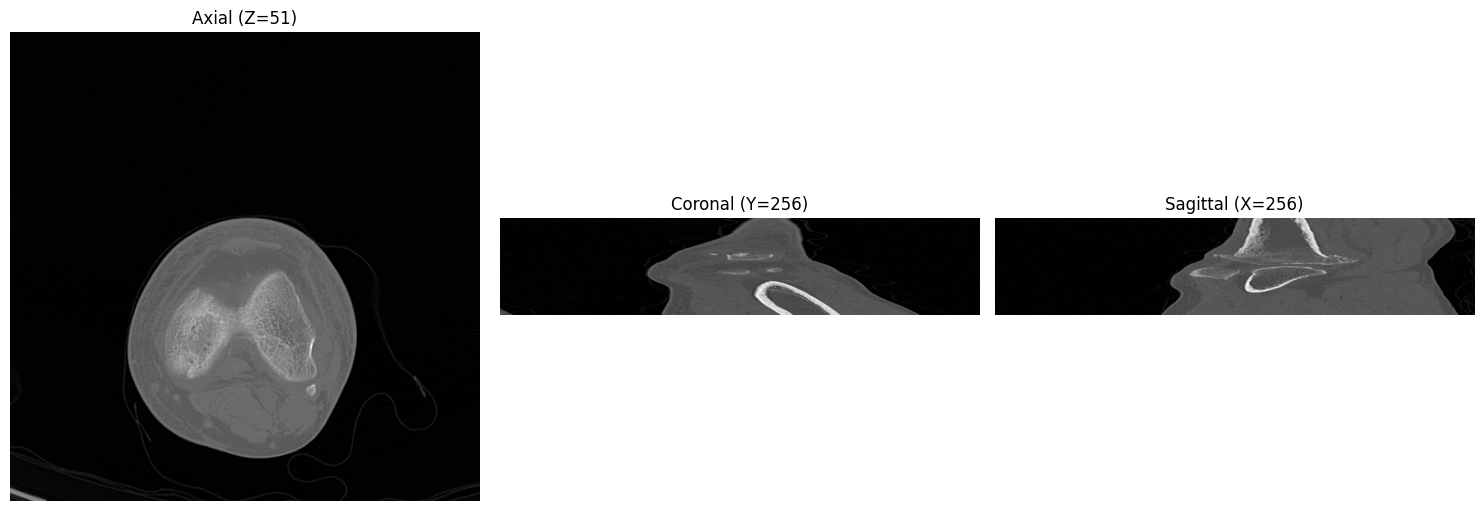

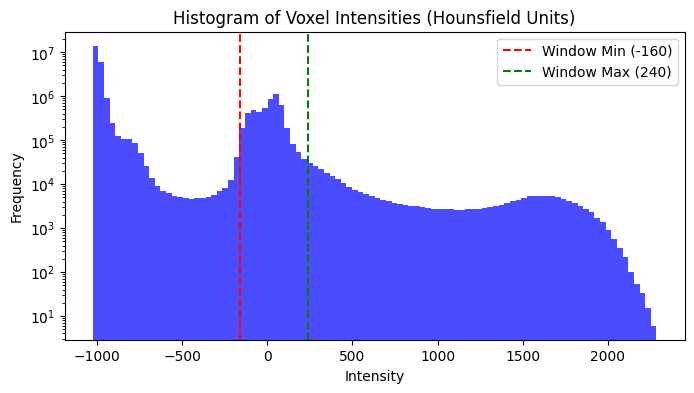

In [10]:
sample_case = df_cases.iloc[0]
print(f"Visualizing Raw Case: {sample_case['case_id']} ({sample_case['part']})")

reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(sample_case['case_path'])
reader.SetFileNames(dicom_names)
sitk_image = reader.Execute()
image_array = sitk.GetArrayFromImage(sitk_image) # Shape: (Z, Y, X)

z, y, x = image_array.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Axial (XY plane, slice along Z)
axes[0].imshow(image_array[z//2, :, :], cmap='gray')
axes[0].set_title(f"Axial (Z={z//2})")
axes[0].axis('off')

# Coronal (XZ plane, slice along Y)
axes[1].imshow(image_array[:, y//2, :], cmap='gray')
axes[1].set_title(f"Coronal (Y={y//2})")
axes[1].axis('off')

# Sagittal (YZ plane, slice along X)
axes[2].imshow(image_array[:, :, x//2], cmap='gray')
axes[2].set_title(f"Sagittal (X={x//2})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Plot Histogram of intensities
plt.figure(figsize=(8, 4))
plt.hist(image_array.flatten(), bins=100, color='blue', alpha=0.7)
plt.title("Histogram of Voxel Intensities (Hounsfield Units)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.yscale("log")
plt.axvline(x=-160, color='r', linestyle='--', label='Window Min (-160)')
plt.axvline(x=240, color='g', linestyle='--', label='Window Max (240)')
plt.legend()
plt.show()

## 3. The Robust Pre-processing Pipeline (MONAI)
We'll define a full pipeline that handles voxel spacing normalization, formatting, intensity windowing (-160 to 240 HU for soft tissue), and resizing to our target dimension of `526, 526, 256`.

In [22]:
# Define target shape and windowing
TARGET_SHAPE = (526, 526, 256)
HU_MIN = -160.0
HU_MAX = 240.0

preprocessing_pipeline = Compose([
    LoadImaged(keys=["image"], reader="ITKReader"),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(
        keys=["image"], 
        pixdim=(1.0, 1.0, 1.0), 
        mode=("bilinear")
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=HU_MIN,
        a_max=HU_MAX,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),
    Resized(
        keys=["image"], 
        spatial_size=TARGET_SHAPE,
        mode="trilinear"
    )
])

# Prepare a list of dictionaries for MONAI Dataset
monai_data_dicts = [{"image": row["case_path"], "case_id": row["case_id"]} for _, row in df_cases.iterrows()]

# Create a Dataset
# We use standard Dataset here, but CacheDataset can be used in production for faster memory caching
dataset = Dataset(data=monai_data_dicts, transform=preprocessing_pipeline)

print(f"MONAI Dataset initialized with {len(dataset)} items.")

MONAI Dataset initialized with 16 items.


## 4. Post-Processing Verification
Let's run our sample case through the MONAI pipeline and inspect the output to ensure the spatial dimensions and intensity standardizations were applied correctly.

Processed Tensor Shape: torch.Size([1, 526, 526, 256])
Processed Min Value: 0.0000
Processed Max Value: 1.0000


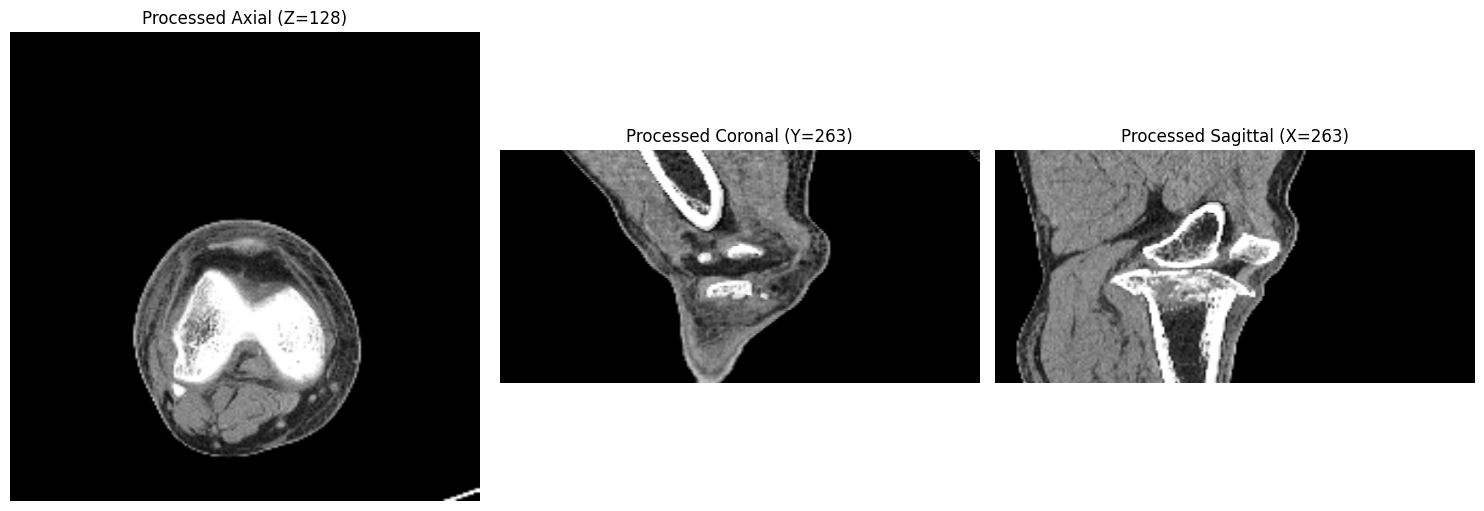

In [23]:
# Get the first item from the dataset
processed_sample = dataset[0]
processed_tensor = processed_sample["image"] # Shape should be (C, X, Y, Z)

print(f"Processed Tensor Shape: {processed_tensor.shape}")
print(f"Processed Min Value: {processed_tensor.min():.4f}")
print(f"Processed Max Value: {processed_tensor.max():.4f}")

# Extract numpy array for plotting (removing channel dim)
proc_array = processed_tensor[0].numpy() 
px, py, pz = proc_array.shape # Note: MONAI puts spatial dimensions as X, Y, Z

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By default, MONAI returns tensors with shape (C, X, Y, Z). 
# However, matplotlib imshow expects (Row, Col), so we'll slice and transpose carefully.

# Axial (XY plane, slice along Z)
axes[0].imshow(proc_array[:, :, pz//2].T, cmap='gray', origin='lower')
axes[0].set_title(f"Processed Axial (Z={pz//2})")
axes[0].axis('off')

# Coronal (XZ plane, slice along Y)
axes[1].imshow(proc_array[:, py//2, :].T, cmap='gray', origin='lower')
axes[1].set_title(f"Processed Coronal (Y={py//2})")
axes[1].axis('off')

# Sagittal (YZ plane, slice along X)
axes[2].imshow(proc_array[px//2, :, :].T, cmap='gray', origin='lower')
axes[2].set_title(f"Processed Sagittal (X={px//2})")
axes[2].axis('off')

plt.tight_layout()
plt.show()